In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
covid_data=pd.read_csv("estimated-cumulative-excess-deaths-per-100000-people-during-covid-19.csv")
covid_data

,Entity,Code,Day,Central estimate,"Lower bound, 95% uncertainty interval",Upper bound,"Confirmed COVID-19 deaths (per 100,000)"
0,Afghanistan,AFG,2020-01-01,-0.022148,-0.289158,0.420465,NaN
1,Afghanistan,AFG,2020-01-04,NaN,NaN,NaN,0.000000
2,Afghanistan,AFG,2020-01-05,NaN,NaN,NaN,0.000000
3,Afghanistan,AFG,2020-01-06,-0.044295,-0.570486,0.848026,0.000000
4,Afghanistan,AFG,2020-01-07,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...
559655,Zimbabwe,ZWE,2026-02-18,NaN,NaN,NaN,35.720818
559656,Zimbabwe,ZWE,2026-02-19,NaN,NaN,NaN,35.720818
559657,Zimbabwe,ZWE,2026-02-20,NaN,NaN,NaN,35.720818
559658,Zimbabwe,ZWE,2026-02-21,NaN,NaN,NaN,35.720818


In [5]:
covid_np=covid_data[covid_data["Entity"]=="Nepal"]
covid_np.head(20)

,Entity,Code,Day,Central estimate,"Lower bound, 95% uncertainty interval",Upper bound,"Confirmed COVID-19 deaths (per 100,000)"
341630,Nepal,NPL,2020-01-01,0.117430,-0.206622,0.359181,NaN
341631,Nepal,NPL,2020-01-04,NaN,NaN,NaN,0.0
341632,Nepal,NPL,2020-01-05,NaN,NaN,NaN,0.0
341633,Nepal,NPL,2020-01-06,0.234653,-0.413637,0.719266,0.0
341634,Nepal,NPL,2020-01-07,NaN,NaN,NaN,0.0
341635,Nepal,NPL,2020-01-08,NaN,NaN,NaN,0.0
341636,Nepal,NPL,2020-01-09,NaN,NaN,NaN,0.0
341637,Nepal,NPL,2020-01-10,NaN,NaN,NaN,0.0
341638,Nepal,NPL,2020-01-11,NaN,NaN,NaN,0.0
341639,Nepal,NPL,2020-01-12,NaN,NaN,NaN,0.0


In [6]:
covid_npday=pd.to_datetime(covid_np["Day"])

In [7]:
covid_np

,Entity,Code,Day,Central estimate,"Lower bound, 95% uncertainty interval",Upper bound,"Confirmed COVID-19 deaths (per 100,000)"
341630,Nepal,NPL,2020-01-01,0.117430,-0.206622,0.359181,NaN
341631,Nepal,NPL,2020-01-04,NaN,NaN,NaN,0.00000
341632,Nepal,NPL,2020-01-05,NaN,NaN,NaN,0.00000
341633,Nepal,NPL,2020-01-06,0.234653,-0.413637,0.719266,0.00000
341634,Nepal,NPL,2020-01-07,NaN,NaN,NaN,0.00000
...,...,...,...,...,...,...,...
343868,Nepal,NPL,2026-02-18,NaN,NaN,NaN,40.49747
343869,Nepal,NPL,2026-02-19,NaN,NaN,NaN,40.49747
343870,Nepal,NPL,2026-02-20,NaN,NaN,NaN,40.49747
343871,Nepal,NPL,2026-02-21,NaN,NaN,NaN,40.49747


In [8]:

cols_to_fix = ['Central estimate', 'Lower bound, 95% uncertainty interval', 'Upper bound']
covid_np[cols_to_fix] = covid_np[cols_to_fix].interpolate()

C:\Users\Loq\AppData\Local\Temp\ipykernel_36312\1854361218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_np[cols_to_fix] = covid_np[cols_to_fix].interpolate()


In [9]:
covid_np

,Entity,Code,Day,Central estimate,"Lower bound, 95% uncertainty interval",Upper bound,"Confirmed COVID-19 deaths (per 100,000)"
341630,Nepal,NPL,2020-01-01,0.117430,-0.206622,0.359181,NaN
341631,Nepal,NPL,2020-01-04,0.156505,-0.275627,0.479209,0.00000
341632,Nepal,NPL,2020-01-05,0.195579,-0.344632,0.599238,0.00000
341633,Nepal,NPL,2020-01-06,0.234653,-0.413637,0.719266,0.00000
341634,Nepal,NPL,2020-01-07,0.254827,-0.447781,0.768294,0.00000
...,...,...,...,...,...,...,...
343868,Nepal,NPL,2026-02-18,482.600300,148.220660,636.057560,40.49747
343869,Nepal,NPL,2026-02-19,482.600300,148.220660,636.057560,40.49747
343870,Nepal,NPL,2026-02-20,482.600300,148.220660,636.057560,40.49747
343871,Nepal,NPL,2026-02-21,482.600300,148.220660,636.057560,40.49747


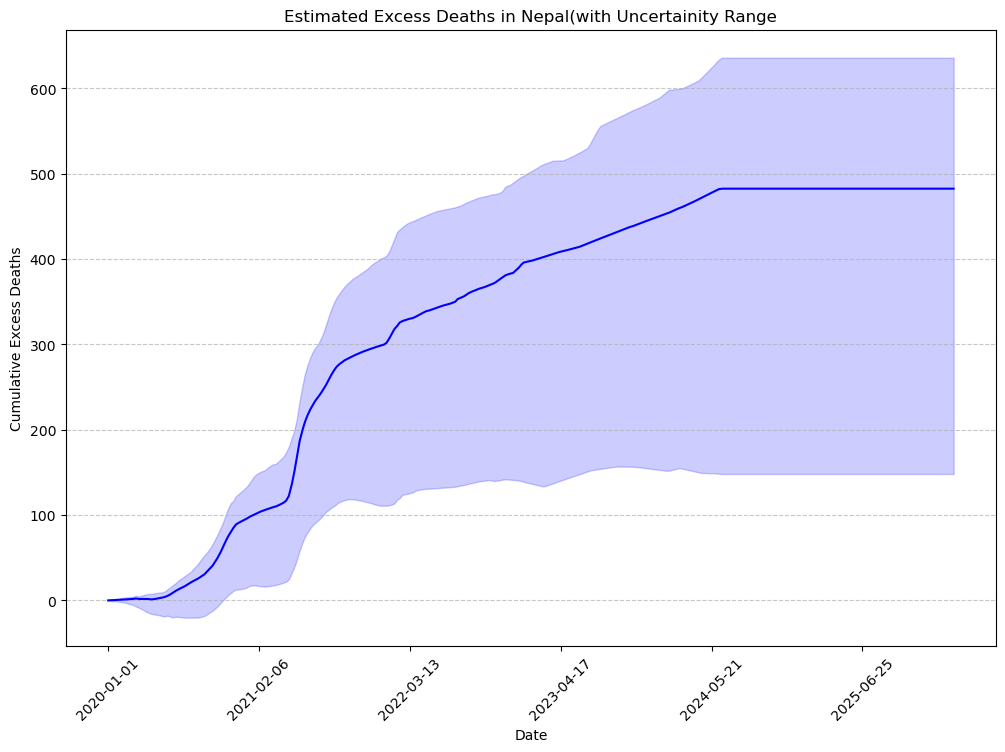

In [23]:
plt.figure(figsize=(12,8))
plt.plot(covid_np["Day"],covid_np["Central estimate"],label="Central estimate",color="blue")
plt.fill_between(covid_np["Day"],covid_np['Lower bound, 95% uncertainty interval'], 
                 covid_np['Upper bound'], 
                 color='blue', alpha=0.2, label='95% Confidence Interval')
plt.title("Estimated Excess Deaths in Nepal(with Uncertainity Range")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel("Cumulative Excess Deaths")
plt.xlabel("Date")
plt.xticks(rotation=45)
import matplotlib.ticker as ticker
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(8))
plt.show()

**What can we infer from the data ?**

- **Firstly,if the shaded area gets wider we can infer that the dataset/the researchers uncertainity level is higher due to poor data collection or no collection**
- **At,early 2020 Nepal was less affected .So,we can see the margin of excess death was nearly zero**
- **-n interval of 2020-2021 ,there was an ongoing increment in excess death with variance**
- **In interval of  2021-2022,there was a steep rise,that implies the affect of C-19  was pitiful at that time.**
- **In interval of 2022-2024 ,the excess death was out of control,the tremendous death took place.but the rate at which people were dying reduced,as slope decreases than that of early phase.**
- **By determining the slope,we can infer that:People could have got vaccinated during this interval**
- **By mid-2024, the pandemic's impact on mortality in Nepal had effectively ended, and the country returned to its baseline health statistics.**